<a href="https://colab.research.google.com/github/yandri918/belajar_machine_learning_buku_ONNO-W-Purba/blob/1April2026/Error_analysis_dasar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv("evaluasi_regresi_rumah.csv")

In [3]:
X = df[["luas_rumah", "jumlah_kamar", "usia_rumah"]]
y = df["harga"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42 )
print(y_test)

0    250000
1    270000
8    500000
5    400000
Name: harga, dtype: int64


In [5]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [11]:
y_pred = model.predict(X_test)
print(y_pred)

[263687.83177547 288310.62044281 502336.18302519 402304.01818643]


In [7]:
hasil = pd.DataFrame({ "aktual": y_test.values, "prediksi": y_pred })

In [8]:
hasil["residual"] = hasil["aktual"] - hasil["prediksi"]
hasil["abs_error"] = hasil["residual"].abs()

In [12]:
print("=== ERROR ANALYSIS DASAR ===")
print(hasil)
print("\nError terbesar:")
print(hasil.sort_values(by="abs_error", ascending=False).head())

=== ERROR ANALYSIS DASAR ===
   aktual       prediksi      residual     abs_error
0  250000  263687.831775 -13687.831775  13687.831775
1  270000  288310.620443 -18310.620443  18310.620443
2  500000  502336.183025  -2336.183025   2336.183025
3  400000  402304.018186  -2304.018186   2304.018186

Error terbesar:
   aktual       prediksi      residual     abs_error
1  270000  288310.620443 -18310.620443  18310.620443
0  250000  263687.831775 -13687.831775  13687.831775
2  500000  502336.183025  -2336.183025   2336.183025
3  400000  402304.018186  -2304.018186   2304.018186


**Plot residual**

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [14]:
df = pd.read_csv("evaluasi_regresi_rumah.csv")

In [15]:
X = df[["luas_rumah", "jumlah_kamar", "usia_rumah"]]
y = df["harga"]

In [18]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42 )


In [19]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [21]:
y_pred = model.predict(X_test)
print(y_test)

0    250000
1    270000
8    500000
5    400000
Name: harga, dtype: int64


In [24]:
residual = y_test.values - y_pred
print(residual)

[-13687.83177547 -18310.62044281  -2336.18302519  -2304.01818643]


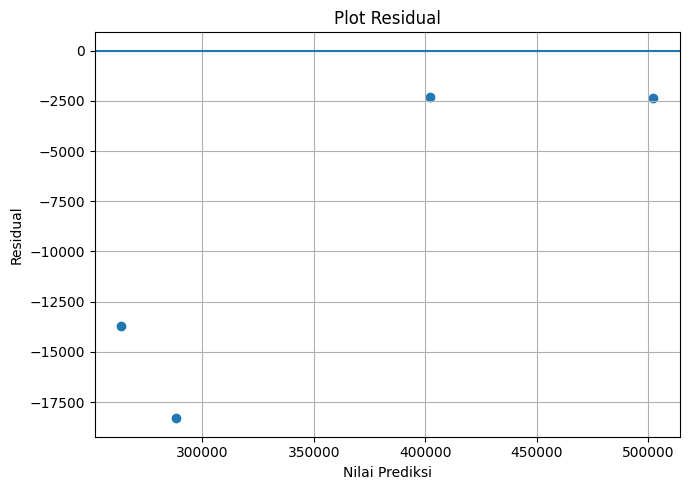

In [25]:
plt.figure(figsize=(7, 5))
plt.axhline(y=0)
plt.scatter(y_pred, residual)
plt.xlabel("Nilai Prediksi")
plt.ylabel("Residual")
plt.title("Plot Residual")
plt.grid(True)
plt.tight_layout()
plt.show()